In [6]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install networkx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import networkx as nx 
import matplotlib.pyplot as plt 

In [34]:
class _Nodo:
    def __init__(self,valor):
        self.valor =valor
        self.nodo_siguiente = None
        self.nodo_anterior = None
class CDLL: 
    def __init__(self):
        self.cabeza = None
        self.cola = None
    def agregar(self, valor):
        nuevo_nodo = _Nodo(valor)
        if self.cabeza is None:
            self.cabeza = nuevo_nodo
            self.cola =nuevo_nodo
        else:
            nuevo_nodo.nodo_anterior=self.cola
            nuevo_nodo.nodo_siguiente=self.cabeza
            self.cola.nodo_siguiente= nuevo_nodo
            self.cabeza.nodo_anterior =nuevo_nodo
            self.cola = nuevo_nodo
            
            
    def reverse(self):
        if self.cabeza is None:
            return
        
        nodo= self.cabeza
        temp = None
        
        while True:
            temp =nodo.nodo_anterior
            nodo.nodo_anterior= nodo.nodo_siguiente
            nodo.nodo_siguiente= temp
            
            nodo = nodo.nodo_anterior
            if nodo == self.cabeza:
                break
            
        temp = self.cabeza
        self.cabeza = self.cola
        self.cola = temp
    
    def listar(self):
        lst =[]
        nodo = self.cabeza
        while nodo:
            lst.append(nodo.valor)
            nodo = nodo.nodo_siguiente
            if nodo == self.cabeza:
                break
        return lst

In [35]:
G=nx.DiGraph()
cdll=CDLL()
cdll.agregar(1)
cdll.agregar(2)
cdll.agregar(3)
cdll.agregar(4)
cdll.agregar(5)
cdll.listar()



[1, 2, 3, 4, 5]

In [36]:
cdll.reverse()
cdll.listar()


[5, 4, 3, 2, 1]

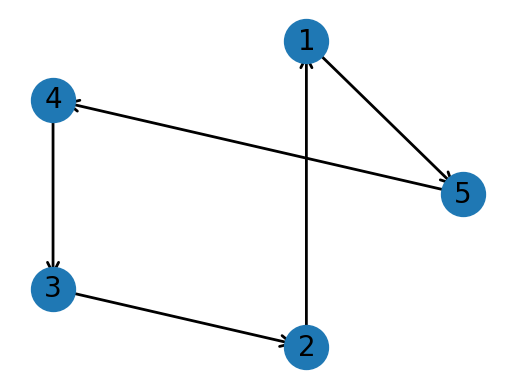

In [37]:
for i, nodos in enumerate(cdll.listar()):
    G.add_node(nodos)
    if i>0:
        G.add_edge(cdll.listar()[i-1],nodos)
    else:
        G.add_edge(cdll.listar()[-1],nodos)
    if i==len(cdll.listar())-1:
        G.add_edge(nodos,cdll.listar()[0])
        
pos=nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size= 1000)
nx.draw_networkx_edges(G, pos,arrowstyle= '->', arrowsize= 20, width= 2)
nx.draw_networkx_labels(G, pos, font_size=20, font_family='sans-serif')
plt.axis('off')
plt.show()


In [ ]:
#ejercicio hecho en clase

In [38]:
class nodoD:
    def __init__(self,dato):
        self.dato=dato
        self.izq=None
        self.der=None
    def __str__(self):
        return str(self.dato)

In [42]:
class listaCirDoble:
    def __init__(self):
        self.I=None
        self.D=None
    def append(self,dato):
        aux=nodoD(dato)
        if self.I is None:
            self.I= self.D=aux
        else: 
            aux.izq=self.D
            aux.der=self.I
            self.D.der=aux
            self.I.izq=aux
            self.D=aux

    #encontrar los numeros que más se repiten
    def repite(self):
        x=self.I
        cv=0
        cvmax=0
        dato=None
        while True:
            cv=0
            y=self.I
            while True:
                if x.dato==y.dato:cv+=1
                y=y.der
                if y==self.I:break
            if cv > cvmax:
                dato=x.dato
                cvmax=cv
            x=x.der
            if x==self.I:break
        return dato

    #eliminar 
    def eliminar (self,dato):
        x=self.I
        while x.dato!=dato:
            x=x.der
     
        if x==self.I and self.D ==x:
            self.I=self.D=None
        elif x==self.I:
            self.I==self.I.der
            self.I.izq=self.D
        elif x==self.D:
            self.D==self.D.izq
            self.D.der=self.I
        else: 
            x.der.izq=x.izq
            x.izq.der=x.der
    
    #Eliminar los numeros que más se repiten
    def emRepite(self):
        x=self.I
        dato=self.repite()
        while True:
            if dato==x.dato:
                self.eliminar(dato)
            x=x.der
            if x==self.I:break

    def listar(self):
        L=[]
        x=self.I
        while True:
            L.append(x)
            x=x.der
            if x==self.I:break
        return L

In [43]:
G=nx.DiGraph()
Lx=listaCirDoble()
Lx.append(21)
Lx.append(32)
Lx.append(15)
Lx.append(15)
Lx.append(15)
Lx.append(56)
Lx.append(6)
Lx.append(16)


In [44]:
G=nx.DiGraph()
for i, nodos in enumerate(Lx.listar()):
    G.add_node(nodos)
    if i>0:
        G.add_edge(Lx.listar()[i-1],nodos)
    else:
        G.add_edge(Lx.listar()[-1],nodos)
    if i==len(Lx.listar())-1:
        G.add_edge(nodos,Lx.listar()[0])

In [224]:
for x in Lx.listar():
    print(x.dato)

21
32
15
15
15
56
6
16


In [225]:
Lx.repite()

15

In [229]:
Lx.emRepite()

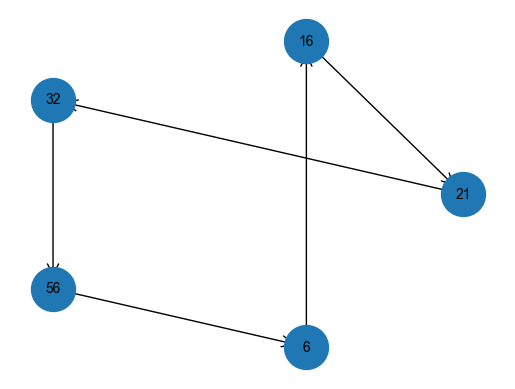

In [230]:
pos=nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size= 1000)
nx.draw_networkx_edges(G, pos,arrowstyle= '->', arrowsize= 20, width= 1)
nx.draw_networkx_labels(G, pos, font_size=10, font_family='arial')
plt.axis('off')
plt.show()